# batch=4, global 2 + local 8 → student 출력은 왜 $(40, K)$ 인가

DINO의 `MultiCropWrapper` 는 crop 리스트를 받아 **한 개의 텐서**를 돌려준다.

$$
\text{student}\big([\,x^{(0)},\dots,x^{(9)}\,]\big)\ \in\ \mathbb{R}^{(2+N)B \times K},
\qquad B=4,\ N=8,\ (2+8)\times 4 = 40
$$

teacher는 `images[:2]` (global crop 2개)만 통과시키므로

$$
\text{teacher}\big([\,x^{(0)},x^{(1)}\,]\big)\ \in\ \mathbb{R}^{2B \times K} = \mathbb{R}^{8 \times K}
$$

이 노트북은 실제 `MultiCropWrapper(vit_tiny(), DINOHead(192, 64))` 를 돌려
$(40,64)$ / $(8,64)$ 를 실측하고, 그 **40행이 어떤 (crop, 배치) 순서로 쌓이는지**까지 확인한다.

In [1]:
# 필요 패키지: torch(2.4), plotly(6.9), kaleido, numpy
# facebookresearch/dino 체크아웃 경로가 필요하다 (utils.py, vision_transformer.py).
import os
import sys

import torch
import torch.nn as nn

DINO_ROOT = "/home/sungwoo/projects/swcho/dino"
sys.path.insert(0, DINO_ROOT)

import utils                      # noqa: E402  MultiCropWrapper
import vision_transformer as vits  # noqa: E402  vit_tiny, DINOHead

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
torch.manual_seed(0)


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. 입력: crop 리스트는 텐서 1개가 아니라 **리스트**다

`DataAugmentationDINO` 는 이미지 1장당 crop $2+N$ 개를 만들고, DataLoader가 이를 배치로 묶는다.
그래서 모델이 받는 것은 길이 $2+N$ 인 리스트이고, **각 원소가 배치 텐서**다.

$$
x^{(v)} \in \mathbb{R}^{B \times 3 \times H_v \times W_v},\qquad
H_v = 224\ (v<2),\quad H_v = 96\ (v\ge 2)
$$

In [2]:
B = 4                  # batch_size_per_gpu
N_LOCAL = 8            # local_crops_number
K = 64                 # out_dim (원래 DINO 기본값은 65536)

images = [torch.randn(B, 3, 224, 224) for _ in range(2)] \
       + [torch.randn(B, 3, 96, 96) for _ in range(N_LOCAL)]

print("len(images)      :", len(images))
print("해상도 리스트     :", [im.shape[-1] for im in images])
print("각 원소 shape    :", [tuple(im.shape) for im in images[:3]], "...")
print("총 이미지 장수    :", sum(im.shape[0] for im in images))

len(images)      : 10
해상도 리스트     : [224, 224, 96, 96, 96, 96, 96, 96, 96, 96]
각 원소 shape    : [(4, 3, 224, 224), (4, 3, 224, 224), (4, 3, 96, 96)] ...
총 이미지 장수    : 40


## 2. 실제 `MultiCropWrapper` 로 실측

`vit_tiny` 의 `embed_dim = 192` 이므로 head는 `DINOHead(192, K)`.
forward pre-hook을 걸어 **backbone이 몇 번 호출되는지**도 같이 본다.

In [3]:
def build(K=K):
    return utils.MultiCropWrapper(
        vits.vit_tiny(patch_size=16),
        vits.DINOHead(192, K, use_bn=False, norm_last_layer=True),
    )


student = build().eval()
teacher = build().eval()

calls = []
h = student.backbone.register_forward_pre_hook(lambda m, inp: calls.append(tuple(inp[0].shape)))
with torch.no_grad():
    s_out = student(images)          # crop 10개 전부
    t_out = teacher(images[:2])      # global 2개만
h.remove()

print("backbone 호출 횟수 :", len(calls))
for c in calls:
    print("   ", c)
print("student 출력 shape :", tuple(s_out.shape))
print("teacher 출력 shape :", tuple(t_out.shape))
print(f"검산: (2+{N_LOCAL}) x {B} = {(2 + N_LOCAL) * B}")

/home/sungwoo/miniforge3/envs/trellis/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


backbone 호출 횟수 : 2
    (8, 3, 224, 224)
    (32, 3, 96, 96)
student 출력 shape : (40, 64)
teacher 출력 shape : (8, 64)
검산: (2+8) x 4 = 40


crop 10개인데 backbone은 **2번**만 돈다. `MultiCropWrapper.forward` 가

```python
idx_crops = torch.cumsum(torch.unique_consecutive(
    torch.tensor([inp.shape[-1] for inp in x]), return_counts=True)[1], 0)
```

로 해상도가 같은 연속 구간을 묶기 때문이다:
`[224,224,96,...,96]` → counts `[2,8]` → cumsum `[2,10]` → `cat(x[0:2])`, `cat(x[2:10])`.
특징을 concat한 뒤 **head는 마지막에 한 번만** 통과한다 (그래서 출력이 40행 한 덩어리).

In [4]:
# 그룹핑 로직만 떼어내 재현
sizes = torch.tensor([im.shape[-1] for im in images])
vals, counts = torch.unique_consecutive(sizes, return_counts=True)
idx_crops = torch.cumsum(counts, 0)
print("해상도 그룹 :", vals.tolist(), " counts :", counts.tolist())
print("idx_crops   :", idx_crops.tolist())
start = 0
for end in idx_crops.tolist():
    print(f"   cat(x[{start}:{end}]) -> {tuple(torch.cat(images[start:end]).shape)}")
    start = end

해상도 그룹 : [224, 96]  counts : [2, 8]
idx_crops   : [2, 10]
   cat(x[0:2]) -> (8, 3, 224, 224)
   cat(x[2:10]) -> (32, 3, 96, 96)


## 3. 40행의 순서: 행 $r$ → crop $\lfloor r/B \rfloor$, 배치 $r \bmod B$

`torch.cat` 은 순서를 보존하므로 **crop-major, batch-minor** 로 쌓인다.

$$
\text{row}(v, i) = v \cdot B + i,\qquad v \in [0, 2+N),\ i \in [0, B)
$$

ViT 대신 **입력에 (crop, 배치) 마커를 새기고 그것을 그대로 읽어내는 stub backbone** 을 써서
직접 확인한다. 각 crop의 각 배치 원소를 상수 $v \cdot 100 + i$ 로 채운다.

In [5]:
class MarkerBackbone(nn.Module):
    """입력 픽셀 상수값(= crop*100 + batch)을 그대로 1차원 특징으로 돌려준다."""
    def forward(self, x):                  # x: (n, 3, H, W)
        return x.mean(dim=(1, 2, 3), keepdim=False).unsqueeze(1)  # (n, 1)


marked = []
for v in range(2 + N_LOCAL):
    hw = 224 if v < 2 else 96
    t = torch.stack([torch.full((3, hw, hw), float(v * 100 + i)) for i in range(B)])
    marked.append(t)

probe = utils.MultiCropWrapper(MarkerBackbone(), nn.Identity())
with torch.no_grad():
    tag = probe(marked).squeeze(1)         # (40,)

print("tag[:12] :", tag[:12].long().tolist())
ok = all(int(tag[r].item()) == (r // B) * 100 + (r % B) for r in range(40))
print("행 r -> (crop=r//B, batch=r%B) 규칙 성립 :", ok)
print("행 0,1,2,3 -> crop0의 배치0~3 / 행 4~7 -> crop1 / 행 8~11 -> crop2(local 첫 번째)")

tag[:12] : [0, 1, 2, 3, 100, 101, 102, 103, 200, 201, 202, 203]
행 r -> (crop=r//B, batch=r%B) 규칙 성립 : True
행 0,1,2,3 -> crop0의 배치0~3 / 행 4~7 -> crop1 / 행 8~11 -> crop2(local 첫 번째)


## 4. `DINOLoss` 가 이 40행을 다시 view로 쪼개는 방법

```python
student_out = (student_output / self.student_temp).chunk(self.ncrops)   # 10조각
teacher_out = F.softmax((teacher_output - self.center) / temp, dim=-1).detach().chunk(2)
```

`chunk(ncrops)` 는 40행을 균등 10등분 → 각 조각이 $(B, K) = (4, 64)$, 즉 **crop 하나의 배치**다.
teacher는 `chunk(2)` → $(4,64)$ 두 조각. 손실 항 개수는 $|\mathcal{N}| = 2(2+N) - 2 = 18$.

In [6]:
s_chunks = s_out.chunk(2 + N_LOCAL)
t_chunks = t_out.chunk(2)
print("student chunk 개수 :", len(s_chunks), " 각 shape :", tuple(s_chunks[0].shape))
print("teacher chunk 개수 :", len(t_chunks), " 각 shape :", tuple(t_chunks[0].shape))

# marker 텐서로 "조각 v = crop v" 임을 확인
tag_chunks = tag.chunk(2 + N_LOCAL)
print("chunk별 첫 원소    :", [int(c[0].item()) for c in tag_chunks])

n_terms = sum(1 for iq in range(2) for v in range(2 + N_LOCAL) if v != iq)
print(f"손실 항 개수 |N|   : {n_terms}  (= 2(2+{N_LOCAL}) - 2)")

student chunk 개수 : 10  각 shape : (4, 64)
teacher chunk 개수 : 2  각 shape : (4, 64)
chunk별 첫 원소    : [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
손실 항 개수 |N|   : 18  (= 2(2+8) - 2)


## 5. `local_crops_number` 를 바꾸면 행 수가 어떻게 변하나

$$
\text{rows}_{\text{student}} = (2+N)\,B,\qquad
\text{rows}_{\text{teacher}} = 2B \ \ (\text{$N$ 과 무관})
$$

In [7]:
rows = []
for n_local in (0, 4, 8):
    imgs = [torch.randn(B, 3, 224, 224) for _ in range(2)] \
         + [torch.randn(B, 3, 96, 96) for _ in range(n_local)]
    with torch.no_grad():
        so = student(imgs)
        to = teacher(imgs[:2])
    rows.append((n_local, tuple(so.shape), tuple(to.shape), 2 * (2 + n_local) - 2))

print(f"{'N(local)':>8} | {'student':>12} | {'teacher':>10} | {'|N| 항수':>8}")
print("-" * 50)
for n_local, ss, ts, nt in rows:
    print(f"{n_local:>8} | {str(ss):>12} | {str(ts):>10} | {nt:>8}")

N(local) |      student |    teacher |   |N| 항수
--------------------------------------------------
       0 |      (8, 64) |    (8, 64) |        2
       4 |     (24, 64) |    (8, 64) |       10
       8 |     (40, 64) |    (8, 64) |       18


$N=0$ 이면 student와 teacher가 똑같이 $(8,64)$ — multi-crop이 꺼진 상태이고
local-to-global 항이 사라져 $|\mathcal{N}| = 2$ (global 교차쌍 2개)만 남는다.

## 6. 시각화: 40행 = crop(10) × batch(4) 격자

각 칸의 숫자가 student 출력의 행 인덱스 $r$ 다. 위 2줄(global)만 teacher가 본다.

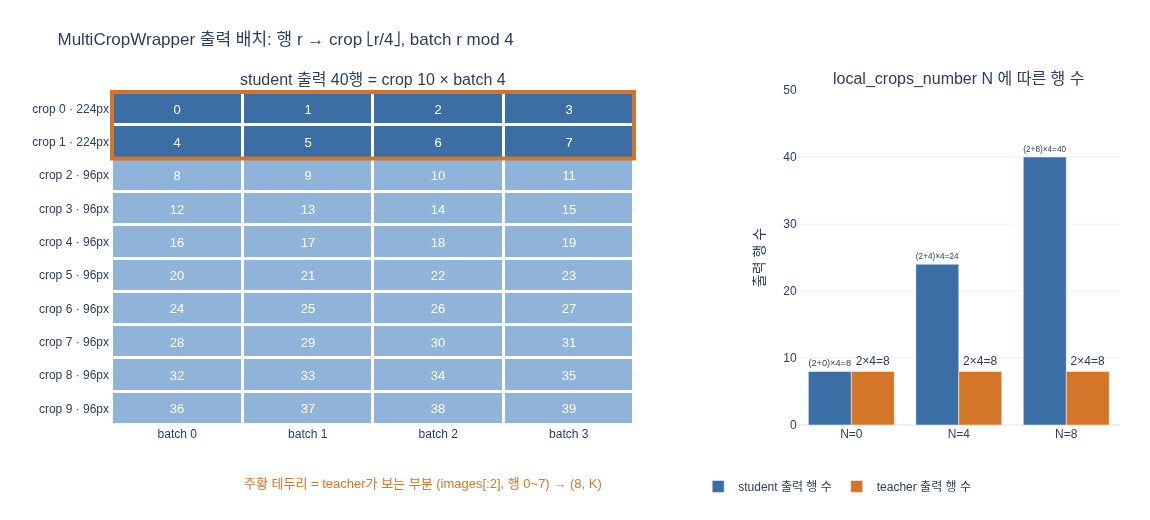

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/e71efdab-8480-4f05-bea4-499128149376/expy.png


In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

NCROPS = 2 + N_LOCAL
C_GLOBAL, C_LOCAL, C_TEACH = "#3b6ea5", "#8fb3d9", "#d4762a"

z = [[0 if v < 2 else 1 for _ in range(B)] for v in range(NCROPS)]
text = [[str(v * B + i) for i in range(B)] for v in range(NCROPS)]
ylab = [f"crop {v} · {224 if v < 2 else 96}px" for v in range(NCROPS)]

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.62, 0.38], horizontal_spacing=0.16,
    subplot_titles=("student 출력 40행 = crop 10 × batch 4",
                    "local_crops_number N 에 따른 행 수"),
)

fig.add_trace(go.Heatmap(
    z=z, text=text, texttemplate="%{text}", textfont={"size": 13, "color": "white"},
    x=[f"batch {i}" for i in range(B)], y=ylab,
    colorscale=[[0, C_GLOBAL], [1, C_LOCAL]], showscale=False,
    xgap=3, ygap=3, hovertemplate="%{y} / %{x}<br>row r=%{text}<extra></extra>",
), row=1, col=1)

# teacher가 보는 영역(global 2 crop = 행 0~7) 강조
fig.add_shape(type="rect", x0=-0.5, x1=B - 0.5, y0=-0.5, y1=1.5,
              line={"color": C_TEACH, "width": 4}, row=1, col=1)
fig.add_annotation(x=0.31, y=-0.145, xref="paper", yref="paper",
                   text="주황 테두리 = teacher가 보는 부분 (images[:2], 행 0~7) → (8, K)",
                   showarrow=False, xanchor="center", yanchor="top",
                   font={"color": C_TEACH, "size": 13})

ns = [0, 4, 8]
fig.add_trace(go.Bar(
    x=[f"N={n}" for n in ns], y=[(2 + n) * B for n in ns],
    text=[f"(2+{n})×{B}={(2 + n) * B}" for n in ns], textposition="outside",
    marker_color=C_GLOBAL, name="student 출력 행 수", showlegend=True,
), row=1, col=2)
fig.add_trace(go.Bar(
    x=[f"N={n}" for n in ns], y=[2 * B] * 3,
    text=[f"2×{B}={2 * B}"] * 3, textposition="outside",
    marker_color=C_TEACH, name="teacher 출력 행 수", showlegend=True,
), row=1, col=2)

fig.update_yaxes(autorange="reversed", row=1, col=1)
fig.update_yaxes(title_text="출력 행 수", range=[0, 50], row=1, col=2)
fig.update_layout(
    title="MultiCropWrapper 출력 배치: 행 r → crop ⌊r/4⌋, batch r mod 4",
    template="plotly_white", width=1150, height=520, barmode="group",
    legend={"orientation": "h", "x": 0.72, "y": -0.14, "xanchor": "center"},
    margin={"l": 110, "r": 30, "t": 90, "b": 95},
)

_show(fig)
png = os.path.join(HERE, "expy.png")
fig.write_image(png, scale=2)
print("saved:", png)

## 정리

* student: 리스트 전체 $(2+N)$ crop × $B$ 배치 → $(2+N)B \times K$. 여기서는 $(40, 64)$.
* teacher: `images[:2]` 만 → $2B \times K = (8, 64)$. $N$ 을 바꿔도 불변.
* 행 배열은 crop-major: 행 $r$ ↔ (crop $\lfloor r/B\rfloor$, batch $r \bmod B$).
  그래서 `chunk(ncrops)` / `chunk(2)` 가 정확히 crop 단위 $(B,K)$ 조각을 준다.
* backbone 호출은 crop 수(10)가 아니라 **해상도 종류 수(2)** 만큼, head는 1번.